In [1]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_auc_score, roc_curve
import statsmodels.api as sm
import scorecardpy as sc

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print('Libraries loaded successfully')

/Users/shivamverma/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Libraries loaded successfully


In [2]:
base = os.path.join(
    os.path.expanduser('~'), 'Desktop',
    'Credit-Risk-Analytics-Portfolio',
    '01_scorecard_development'
)

# Load WOE transformed datasets
train_woe = pd.read_csv(os.path.join(base, 'data', 'train_woe.csv'))
oot_woe   = pd.read_csv(os.path.join(base, 'data', 'oot_woe.csv'))

# Load scored datasets and coefficients from notebook 04
train_scored = pd.read_csv(os.path.join(base, 'outputs', 'train_scored.csv'))
oot_scored   = pd.read_csv(os.path.join(base, 'outputs', 'oot_scored.csv'))
coef_df      = pd.read_csv(os.path.join(base, 'outputs', 'model_coefficients.csv'))

print('Data loaded')
print(f'Train WOE : {train_woe.shape}')
print(f'OOT WOE   : {oot_woe.shape}')
print(f'Coefficients: {len(coef_df)} variables')

Data loaded
Train WOE : (246008, 12)
OOT WOE   : (61503, 12)
Coefficients: 11 variables


In [3]:
# Rebuild logistic regression model
# This produces identical results to notebook 04 because same data and random_state

feature_cols = [c for c in train_woe.columns if c != 'TARGET']

X_train = train_woe[feature_cols]
y_train = train_woe['TARGET']
X_oot   = oot_woe[feature_cols]
y_oot   = oot_woe['TARGET']

X_train_sm = sm.add_constant(X_train)
X_oot_sm   = sm.add_constant(X_oot)

logit_model = sm.Logit(y_train, X_train_sm)
result      = logit_model.fit(maxiter=200, disp=False)

print('Model rebuilt successfully')
print(f'Converged: {result.mle_retvals["converged"]}')

Model rebuilt successfully
Converged: True


In [4]:
# Scaling parameters
PDO        = 20    # Points to Double the Odds
BASE_SCORE = 600   # Score at base odds
BASE_ODDS  = 50    # Odds of good to bad at base score (50:1)

# Derived scaling constants
# Factor converts log-odds units to score points
# Offset shifts the score to the correct base level
FACTOR = PDO / np.log(2)
OFFSET = BASE_SCORE - FACTOR * np.log(BASE_ODDS)

print('Scorecard Scaling Parameters')
print('='*45)
print(f'PDO        : {PDO}')
print(f'Base Score : {BASE_SCORE}')
print(f'Base Odds  : {BASE_ODDS}:1')
print(f'Factor     : {FACTOR:.4f}')
print(f'Offset     : {OFFSET:.4f}')
print()
print('Interpretation:')
print(f'  Score of {BASE_SCORE} = odds of {BASE_ODDS}:1 (good:bad)')
print(f'  Every {PDO} point increase doubles the odds of being good')
print(f'  Score of {BASE_SCORE+PDO} = odds of {BASE_ODDS*2}:1')
print(f'  Score of {BASE_SCORE-PDO} = odds of {BASE_ODDS//2}:1')

Scorecard Scaling Parameters
PDO        : 20
Base Score : 600
Base Odds  : 50:1
Factor     : 28.8539
Offset     : 487.1229

Interpretation:
  Score of 600 = odds of 50:1 (good:bad)
  Every 20 point increase doubles the odds of being good
  Score of 620 = odds of 100:1
  Score of 580 = odds of 25:1


In [5]:
# Extract intercept and coefficients from model
intercept    = result.params['const']
coefficients = result.params.drop('const')

print('Model Coefficients for Scaling')
print('='*55)
print(f'Intercept : {intercept:.4f}')
print()
print(f'{"Variable":<45} {"Coefficient":>12}')
print('-'*58)
for var, coef in coefficients.items():
    print(f'{var:<45} {coef:>12.4f}')

Model Coefficients for Scaling
Intercept : -2.4329

Variable                                       Coefficient
----------------------------------------------------------
DAYS_LAST_PHONE_CHANGE_woe                          0.2486
DAYS_REGISTRATION_woe                               0.2534
EXT_SOURCE_3_woe                                    0.8429
EMPLOYMENT_AGE_RATIO_woe                            0.5512
AGE_YEARS_woe                                       0.2194
DAYS_ID_PUBLISH_woe                                 0.1660
AMT_GOODS_PRICE_woe                                 0.3833
EXT_SOURCE_2_woe                                    0.8358
CREDIT_GOODS_RATIO_woe                              0.7095
AMT_CREDIT_woe                                      0.1365
AMT_INCOME_TOTAL_woe                                0.3625


In [6]:
# Rebuild WOE bins from notebook 03
# We need the original bin boundaries to build the points table

import os, sys
from sklearn.model_selection import train_test_split

# Load raw data and recreate bins
raw_path = os.path.join(base, 'data', 'application_train.csv')
df_raw   = pd.read_csv(raw_path)

# Apply same fixes as notebook 03
df_raw['DAYS_EMPLOYED'] = df_raw['DAYS_EMPLOYED'].replace(365243, np.nan)
if 'CODE_GENDER' in df_raw.columns:
    df_raw['CODE_GENDER'] = df_raw['CODE_GENDER'].replace('XNA', np.nan)

df_raw['AGE_YEARS']           = -df_raw['DAYS_BIRTH'] / 365
df_raw['EMPLOYMENT_YEARS']    = -df_raw['DAYS_EMPLOYED'] / 365
df_raw['CREDIT_INCOME_RATIO'] = df_raw['AMT_CREDIT'] / (df_raw['AMT_INCOME_TOTAL'] + 1)
df_raw['ANNUITY_INCOME_RATIO']= df_raw['AMT_ANNUITY'] / (df_raw['AMT_INCOME_TOTAL'] + 1)
df_raw['CREDIT_GOODS_RATIO']  = df_raw['AMT_CREDIT'] / (df_raw['AMT_GOODS_PRICE'] + 1)
df_raw['EMPLOYMENT_AGE_RATIO']= df_raw['EMPLOYMENT_YEARS'] / (df_raw['AGE_YEARS'] + 1)

# Filter to valid columns
missing_pct = df_raw.isnull().mean()
valid_cols  = missing_pct[missing_pct <= 0.40].index.tolist()
valid_cols  = [c for c in valid_cols if c not in ['SK_ID_CURR']]
if 'TARGET' not in valid_cols:
    valid_cols.append('TARGET')

df_woe = df_raw[valid_cols].copy()

# Split - same random_state as notebook 03 to get identical train set
train_df, oot_df = train_test_split(
    df_woe, test_size=0.2, random_state=42, stratify=df_woe['TARGET']
)

# Get selected variables from WOE columns
selected_vars = [c.replace('_woe', '') for c in feature_cols]
train_selected = train_df[selected_vars + ['TARGET']].copy()

print('Rebuilding WOE bins...')
bins = sc.woebin(train_selected, y='TARGET')
print('WOE bins rebuilt')

Rebuilding WOE bins...
[INFO] creating woe binning ...


/Users/shivamverma/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/shivamverma/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/shivamverma/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/shivamverma/anaconda3/lib/python3.10/site-packages/scorecardpy/woebin.py:38: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_op

/Users/shivamverma/anaconda3/lib/python3.10/site-packages/scorecardpy/woebin.py:425: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: iv_01(x['good'], x['bad'])).reset_index(name='total_iv')
/Users/shivamverma/anaconda3/lib/python3.10/site-packages/scorecardpy/woebin.py:442: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binning_1bst_brk = binning_1bst_brk.groupby(['variable', 'bstbin'], group_keys=False)\
/Users/shivamverma/anaconda3/lib/python3.10/site-packages/scorecardpy/woebin.py:443: FutureWarn

/Users/shivamverma/anaconda3/lib/python3.10/site-packages/scorecardpy/woebin.py:141: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  ).groupby(['variable', 'rowid', 'bin_chr'], group_keys=False).agg({'bad':sum,'good':sum})\
/Users/shivamverma/anaconda3/lib/python3.10/site-packages/scorecardpy/woebin.py:141: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  ).groupby(['variable', 'rowid', 'bin_chr'], group_keys=False).agg({'bad':sum,'good':sum})\
/Users/shivamverma/anaconda3/lib/python3.10/site-packages/scorecardpy/woebin.py:425: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecat

/Users/shivamverma/anaconda3/lib/python3.10/site-packages/scorecardpy/woebin.py:38: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .stack().replace('missing', np.nan) \
/Users/shivamverma/anaconda3/lib/python3.10/site-packages/scorecardpy/woebin.py:141: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  ).groupby(['variable', 'rowid', 'bin_chr'], group_keys=False).agg({'bad':sum,'good':sum})\
/Users/shivamverma/anaconda3/lib/python3.10/site-packages/scorecardpy/woebin.py:141: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a fu

...

/Users/shivamverma/anaconda3/lib/python3.10/site-packages/scorecardpy/woebin.py:425: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: iv_01(x['good'], x['bad'])).reset_index(name='total_iv')
/Users/shivamverma/anaconda3/lib/python3.10/site-packages/scorecardpy/woebin.py:442: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binning_1bst_brk = binning_1bst_brk.groupby(['variable', 'bstbin'], group_keys=False)\
/Users/shivamverma/anaconda3/lib/python3.10/site-packages/scorecardpy/woebin.py:443: FutureWarn

/Users/shivamverma/anaconda3/lib/python3.10/site-packages/scorecardpy/woebin.py:425: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: iv_01(x['good'], x['bad'])).reset_index(name='total_iv')
/Users/shivamverma/anaconda3/lib/python3.10/site-packages/scorecardpy/woebin.py:442: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binning_1bst_brk = binning_1bst_brk.groupby(['variable', 'bstbin'], group_keys=False)\
/Users/shivamverma/anaconda3/lib/python3.10/site-packages/scorecardpy/woebin.py:443: FutureWarn

/Users/shivamverma/anaconda3/lib/python3.10/site-packages/scorecardpy/woebin.py:414: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  .agg({'good':sum, 'bad':sum}).reset_index()\
/Users/shivamverma/anaconda3/lib/python3.10/site-packages/scorecardpy/woebin.py:38: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .stack().replace('missing', np.nan) \
/Users/shivamverma/anaconda3/lib/python3.10/site-packages/scorecardpy/woebin.py:425: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping colu

Binning on 246008 rows and 12 columns in 00:00:13
WOE bins rebuilt


/Users/shivamverma/anaconda3/lib/python3.10/site-packages/scorecardpy/woebin.py:414: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  .agg({'good':sum, 'bad':sum}).reset_index()\
/Users/shivamverma/anaconda3/lib/python3.10/site-packages/scorecardpy/woebin.py:414: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  .agg({'good':sum, 'bad':sum}).reset_index()\
/Users/shivamverma/anaconda3/lib/python3.10/site-packages/scorecardpy/woebin.py:414: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep curren

In [7]:
# Calculate points for each bin of each variable
# This produces the actual scorecard lookup table

scorecard_rows = []

# Base score contribution from intercept
# Distributed evenly across all variables for display
n_vars         = len(coefficients)
base_per_var   = (OFFSET - FACTOR * intercept) / n_vars

for var_woe, coef in coefficients.items():
    # Strip _woe suffix to get original variable name
    var_name = var_woe.replace('_woe', '')

    if var_name not in bins:
        continue

    bin_table = bins[var_name]

    for _, row in bin_table.iterrows():
        woe_val = row['woe']
        bin_label = str(row['bin'])

        # Points formula
        # Negative sign: higher WOE (riskier) = fewer points
        points = round(base_per_var - FACTOR * coef * woe_val)

        scorecard_rows.append({
            'Variable'   : var_name,
            'Bin'        : bin_label,
            'WOE'        : round(woe_val, 4),
            'Coefficient': round(coef, 4),
            'Points'     : int(points),
            'Bin_IV'     : round(row.get('bin_iv', 0), 4),
            'Count'      : int(row.get('count', 0)),
            'Default_Rate': round(row.get('badprob', 0) * 100, 2)
        })

scorecard_df = pd.DataFrame(scorecard_rows)

print('Scorecard Points Table')
print('='*80)
print(scorecard_df.to_string(index=False))
print(f'\nTotal rows in scorecard: {len(scorecard_df)}')

Scorecard Points Table
              Variable                                     Bin     WOE  Coefficient  Points  Bin_IV  Count  Default_Rate
DAYS_LAST_PHONE_CHANGE                                 missing  2.3271       0.2486      34  0.0001      1        0.0000
DAYS_LAST_PHONE_CHANGE                          [-inf,-2200.0) -0.4519       0.2486      54  0.0159  23067        5.2900
DAYS_LAST_PHONE_CHANGE                       [-2200.0,-1100.0) -0.2136       0.2486      52  0.0122  71896        6.6200
DAYS_LAST_PHONE_CHANGE                           [-1100.0,inf)  0.1415       0.2486      50  0.0130 151044        9.1900
     DAYS_REGISTRATION                          [-inf,-9500.0) -0.3727       0.2534      53  0.0146  30203        5.7000
     DAYS_REGISTRATION                       [-9500.0,-7000.0) -0.1565       0.2534      52  0.0037  39640        6.9900
     DAYS_REGISTRATION                       [-7000.0,-5500.0) -0.0434       0.2534      51  0.0002  27679        7.7600
     DAYS

In [8]:
# Save scorecard table
scorecard_df.to_csv(os.path.join(base, 'outputs', 'scorecard_table.csv'), index=False)
print('Scorecard table saved')

# Display clean version grouped by variable
print('\nFINAL SCORECARD TABLE')
print('='*75)
print(f'{"Variable":<35} {"Bin":<25} {"Points":>8}')
print('-'*75)

for var in scorecard_df['Variable'].unique():
    var_rows = scorecard_df[scorecard_df['Variable'] == var]
    print(f'\n  {var}')
    for _, row in var_rows.iterrows():
        bin_short = str(row['Bin'])[:22]
        print(f'  {"":<4} {bin_short:<25} {row["Points"]:>8}')

Scorecard table saved

FINAL SCORECARD TABLE
Variable                            Bin                         Points
---------------------------------------------------------------------------

  DAYS_LAST_PHONE_CHANGE
       missing                         34
       [-inf,-2200.0)                  54
       [-2200.0,-1100.0)               52
       [-1100.0,inf)                   50

  DAYS_REGISTRATION
       [-inf,-9500.0)                  53
       [-9500.0,-7000.0)               52
       [-7000.0,-5500.0)               51
       [-5500.0,-1000.0)               50
       [-1000.0,inf)                   49

  EXT_SOURCE_3
       missing                         47
       [-inf,0.24)                     26
       [0.24,0.42)                     43
       [0.42,0.56)                     55
       [0.56,0.68)                     65
       [0.68,inf)                      73

  EMPLOYMENT_AGE_RATIO
       missing                         58
       [-inf,0.09)                     46
       

In [12]:
# Apply scorecard manually using our own points table
# This is more transparent than using scorecardpy's built-in function
# and avoids the internal variable conflict

# Step 1 — Rebuild WOE transformed datasets using scorecardpy woebin_ply
train_woe_transformed = sc.woebin_ply(train_selected, bins)
oot_woe_transformed   = sc.woebin_ply(
    oot_df[selected_vars + ['TARGET']], bins
)

# Step 2 — Build a lookup dictionary from our scorecard table
# Structure: {variable_woe_col: {woe_value: points}}
points_lookup = {}
for var in scorecard_df['Variable'].unique():
    woe_col    = var + '_woe'
    var_rows   = scorecard_df[scorecard_df['Variable'] == var]
    woe_to_pts = dict(zip(var_rows['WOE'].round(4), var_rows['Points']))
    points_lookup[woe_col] = woe_to_pts

print(f'Points lookup built for {len(points_lookup)} variables')

# Step 3 — Calculate score for each applicant
# Score = sum of points across all variables
def calculate_score(row, lookup):
    total = 0
    for col, woe_pts in lookup.items():
        if col in row.index:
            woe_val = round(row[col], 4)
            # Find nearest WOE value in lookup
            if woe_val in woe_pts:
                total += woe_pts[woe_val]
            else:
                # Find closest WOE value
                closest = min(woe_pts.keys(), key=lambda x: abs(x - woe_val))
                total += woe_pts[closest]
    return total

# Apply to train
woe_cols = [c for c in train_woe_transformed.columns if c.endswith('_woe')]
train_woe_transformed = train_woe_transformed[woe_cols].copy()
oot_woe_transformed   = oot_woe_transformed[woe_cols].copy()

train_score_df = pd.DataFrame()
train_score_df['score'] = train_woe_transformed.apply(
    lambda row: calculate_score(row, points_lookup), axis=1
)
train_score_df['TARGET'] = train_selected['TARGET'].values

oot_score_df = pd.DataFrame()
oot_score_df['score'] = oot_woe_transformed.apply(
    lambda row: calculate_score(row, points_lookup), axis=1
)
oot_score_df['TARGET'] = oot_df['TARGET'].values

print('Scores calculated successfully')
print(f'\nTrain score range: {train_score_df["score"].min():.0f} to {train_score_df["score"].max():.0f}')
print(f'OOT score range  : {oot_score_df["score"].min():.0f} to {oot_score_df["score"].max():.0f}')
print(f'\nTrain mean score : {train_score_df["score"].mean():.1f}')
print(f'OOT mean score   : {oot_score_df["score"].mean():.1f}')

[INFO] converting into woe values ...


/Users/shivamverma/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/shivamverma/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/shivamverma/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Woe transformating on 246008 rows and 11 columns in 00:00:10
[INFO] converting into woe values ...


/Users/shivamverma/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/shivamverma/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/shivamverma/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Points lookup built for 11 variables
Scores calculated successfully

Train score range: 481 to 640
OOT score range  : 481 to 640

Train mean score : 566.0
OOT mean score   : 566.0


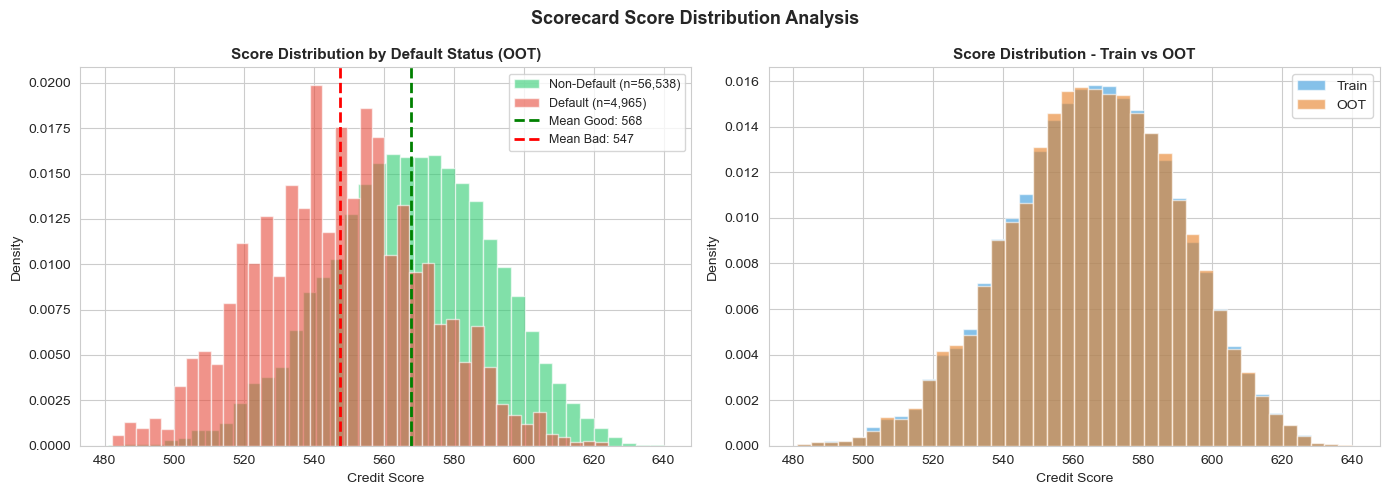

Score distribution chart saved


In [13]:
# Add target to score dataframes for analysis
train_score_df['TARGET'] = train_selected['TARGET'].values
oot_score_df['TARGET']   = oot_df['TARGET'].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score distribution - good vs bad (OOT)
oot_good_scores = oot_score_df[oot_score_df['TARGET']==0]['score']
oot_bad_scores  = oot_score_df[oot_score_df['TARGET']==1]['score']

axes[0].hist(oot_good_scores, bins=40, alpha=0.6,
             color='#2ecc71', label=f'Non-Default (n={len(oot_good_scores):,})', density=True)
axes[0].hist(oot_bad_scores,  bins=40, alpha=0.6,
             color='#e74c3c', label=f'Default (n={len(oot_bad_scores):,})', density=True)
axes[0].axvline(x=oot_good_scores.mean(), color='green',
                linestyle='--', linewidth=2,
                label=f'Mean Good: {oot_good_scores.mean():.0f}')
axes[0].axvline(x=oot_bad_scores.mean(), color='red',
                linestyle='--', linewidth=2,
                label=f'Mean Bad: {oot_bad_scores.mean():.0f}')
axes[0].set_xlabel('Credit Score')
axes[0].set_ylabel('Density')
axes[0].set_title('Score Distribution by Default Status (OOT)',
                  fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)

# Train vs OOT score distribution comparison
axes[1].hist(train_score_df['score'], bins=40, alpha=0.6,
             color='#3498db', label='Train', density=True)
axes[1].hist(oot_score_df['score'],   bins=40, alpha=0.6,
             color='#e67e22', label='OOT', density=True)
axes[1].set_xlabel('Credit Score')
axes[1].set_ylabel('Density')
axes[1].set_title('Score Distribution - Train vs OOT',
                  fontsize=11, fontweight='bold')
axes[1].legend()

plt.suptitle('Scorecard Score Distribution Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(base, 'outputs', '21_score_distribution.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Score distribution chart saved')

In [14]:
# Define score bands
# These cutoffs are illustrative - in practice set by the business
# based on risk appetite and approval rate targets

score_bins   = [0, 500, 540, 580, 620, 660, 700, 9999]
score_labels = [
    'Band 1: <500  Very High Risk',
    'Band 2: 500-540  High Risk',
    'Band 3: 540-580  Medium High Risk',
    'Band 4: 580-620  Medium Risk',
    'Band 5: 620-660  Medium Low Risk',
    'Band 6: 660-700  Low Risk',
    'Band 7: >700   Very Low Risk'
]

oot_score_df['Score_Band'] = pd.cut(
    oot_score_df['score'],
    bins=score_bins,
    labels=score_labels
)

band_summary = oot_score_df.groupby('Score_Band', observed=True).agg(
    Count       =('TARGET', 'count'),
    Defaults    =('TARGET', 'sum'),
    Default_Rate=('TARGET', 'mean'),
    Mean_Score  =('score',  'mean')
).reset_index()

band_summary['Default_Rate_%'] = (band_summary['Default_Rate'] * 100).round(2)
band_summary['Volume_%']       = (band_summary['Count'] / len(oot_score_df) * 100).round(1)
band_summary['Cum_Volume_%']   = band_summary['Volume_%'].cumsum().round(1)

# Recommended decision
def recommend(rate):
    if rate > 20:   return 'Decline'
    elif rate > 12: return 'Manual Review'
    elif rate > 7:  return 'Conditional Approve'
    else:           return 'Auto Approve'

band_summary['Recommendation'] = band_summary['Default_Rate'].apply(recommend)

print('SCORE BAND ANALYSIS (OOT)')
print('='*90)
print(band_summary[['Score_Band','Count','Volume_%',
                     'Default_Rate_%','Recommendation']].to_string(index=False))
print(f'\nOverall default rate: {oot_score_df["TARGET"].mean()*100:.2f}%')

SCORE BAND ANALYSIS (OOT)
                       Score_Band  Count  Volume_%  Default_Rate_% Recommendation
     Band 1: <500  Very High Risk    243    0.4000         44.8600   Auto Approve
       Band 2: 500-540  High Risk   9081   14.8000         20.3200   Auto Approve
Band 3: 540-580  Medium High Risk  34342   55.8000          7.4400   Auto Approve
     Band 4: 580-620  Medium Risk  17459   28.4000          2.5900   Auto Approve
 Band 5: 620-660  Medium Low Risk    378    0.6000          1.0600   Auto Approve

Overall default rate: 8.07%


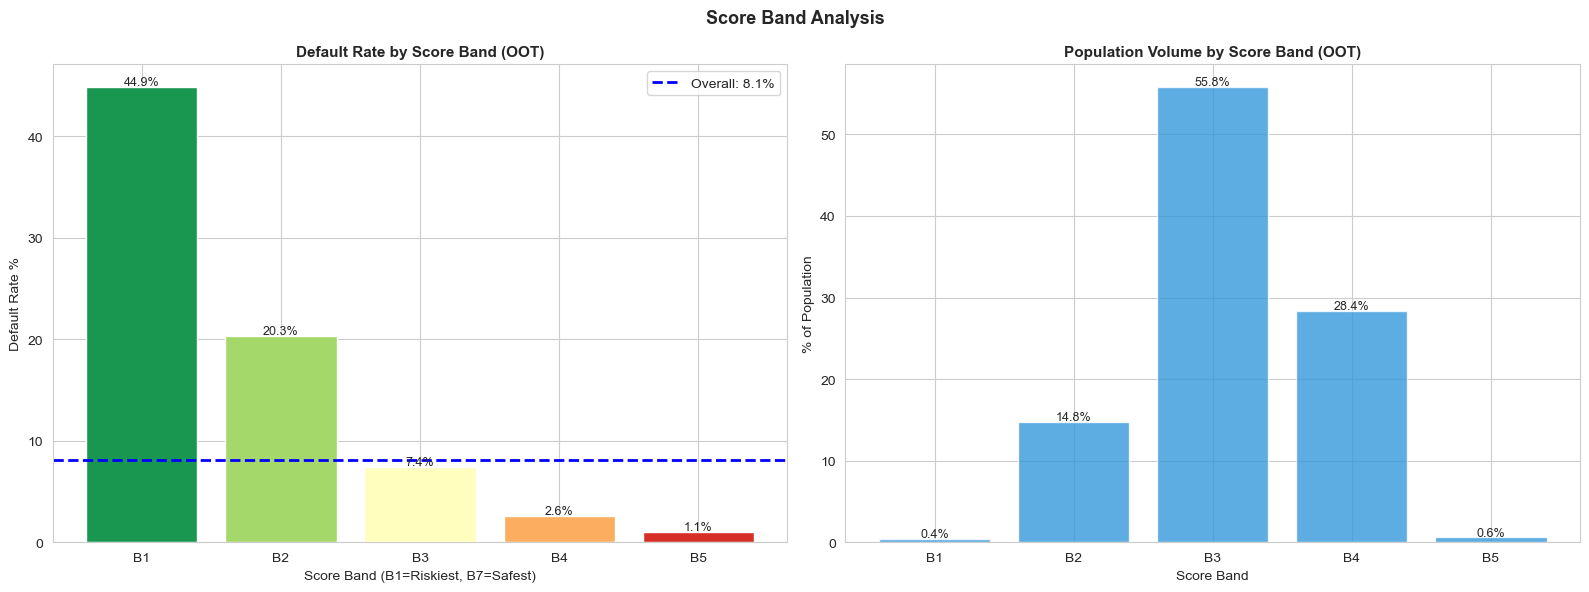

Score band chart saved


In [15]:
# Score band chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

short_labels = [f'B{i+1}' for i in range(len(band_summary))]

# Default rate by band
colors_band = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(band_summary)))
bars = axes[0].bar(short_labels, band_summary['Default_Rate_%'],
                   color=colors_band, edgecolor='white')
axes[0].axhline(y=oot_score_df['TARGET'].mean()*100,
                color='blue', linestyle='--', linewidth=2,
                label=f'Overall: {oot_score_df["TARGET"].mean()*100:.1f}%')
axes[0].set_xlabel('Score Band (B1=Riskiest, B7=Safest)')
axes[0].set_ylabel('Default Rate %')
axes[0].set_title('Default Rate by Score Band (OOT)',
                  fontsize=11, fontweight='bold')
axes[0].legend()
for bar, rate in zip(bars, band_summary['Default_Rate_%']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.2,
                 f'{rate:.1f}%', ha='center', fontsize=9)

# Volume by band
axes[1].bar(short_labels, band_summary['Volume_%'],
            color='#3498db', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Score Band')
axes[1].set_ylabel('% of Population')
axes[1].set_title('Population Volume by Score Band (OOT)',
                  fontsize=11, fontweight='bold')
for i, (_, row) in enumerate(band_summary.iterrows()):
    axes[1].text(i, row['Volume_%'] + 0.2,
                 f'{row["Volume_%"]:.1f}%', ha='center', fontsize=9)

plt.suptitle('Score Band Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(base, 'outputs', '22_score_bands.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Score band chart saved')